# How Old is 47 Tucanae? Estimating the Age of a Globular Cluster with Gaia DR3

**Author:** Xoán Vilas Currás - xoan.cosmo@gmail.com

---

## 1. Introduction: What is 47 Tucanae?

**47 Tucanae** (NGC 104) is one of the most massive and brightest globular clusters in the Milky Way. Visible to the naked eye from the Southern Hemisphere, it appears as a fuzzy star near the Small Magellanic Cloud in the constellation Tucana. It harbours hundreds of thousands of stars packed into a sphere roughly 120 light-years across, at a distance of about 4.4 kpc (~14,000 light-years) from Earth.

Globular clusters are among the oldest structures in the Universe. Because all stars in a cluster form at roughly the same time from the same gas cloud, they act as **cosmic clocks**: by comparing their observed brightness and colours against theoretical stellar evolution models, we can estimate how long those stars have been shining — and therefore the age of the cluster itself.

In this notebook we do exactly that, using real data from the **Gaia DR3** catalogue and theoretical isochrones from the **PARSEC** library.

### What is an isochrone?

An isochrone (from Greek: *isos* = equal, *chronos* = time) is a curve in the colour-magnitude diagram (CMD) that represents all stars of the same age but different masses, as predicted by stellar evolution theory. By overlaying isochrones of different ages on the observed CMD, we can find the one that best matches the data — that is the estimated age of the cluster.

### Key facts about 47 Tuc

| Parameter | Value |
|-----------|-------|
| Distance | ~4.4 kpc |
| Distance modulus | 13.21 mag |
| Metallicity [M/H] | −0.6 |
| Reddening E(B−V) | 0.03 |
| Age (literature) | ~13 Gyr |

---

## 2. Method

Our analysis follows five steps:

1. **Data acquisition** — query Gaia DR3 for stars in the sky region of 47 Tuc
2. **Quality filtering** — remove stars with unreliable photometry or astrometry
3. **Membership selection** — isolate cluster members using proper motions
4. **Extinction correction** — correct observed magnitudes for interstellar dust
5. **Isochrone fitting** — compare the dereddened CMD against a grid of PARSEC isochrones

### 2.1 Data acquisition

Stars were queried from the Gaia DR3 catalogue (`gaiadr3.gaia_source`) via the [Gaia Archive](https://gea.esac.esa.int/archive/) using Advance (ADQL) Search. We selected sources in the sky region of 47 Tuc with a parallax range consistent with its known distance (~4 kpc, corresponding to a parallax of ~0.23 mas):

```sql
SELECT ra, dec, parallax, pmra, pmdec, pmra_error, pmdec_error, radial_velocity,
       phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp,
       phot_bp_rp_excess_factor, phot_bp_mean_flux_over_error,
       phot_rp_mean_flux_over_error, astrometric_excess_noise
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 0.202 AND 0.262
  AND ra BETWEEN 5 AND 7
  AND dec BETWEEN -74 AND -70
```

### 2.2 Quality filtering

Not all Gaia measurements are equally reliable. We apply four quality cuts to remove stars with poor astrometry or photometry:

| Filter | Condition | Rationale |
|--------|-----------|----------|
| Astrometric excess noise | < 1 | Flags sources with poorly modelled astrometric solutions |
| BP flux / error | > 10 | Ensures reliable BP photometry |
| RP flux / error | > 10 | Ensures reliable RP photometry |
| BP/RP excess factor | < 2.5 | Flags blended or contaminated sources |

### 2.3 Membership selection

The sky region we queried contains both cluster members and unrelated foreground/background field stars. We separate them using **proper motions** — the apparent motion of stars across the sky.

All stars belonging to 47 Tuc share the same bulk motion (the cluster moves as a whole), so they form a tight clump in the proper motion diagram (μ_α*, μ_δ). We select stars within a circle of radius 1 mas/yr around the median proper motion of the sample:

$$( \mu_{\alpha*} - \bar{\mu}_{\alpha*})^2 + (\mu_\delta - \bar{\mu}_\delta)^2 \leq r^2$$

### 2.4 Extinction correction

Interstellar dust reddens and dims starlight. Even though 47 Tuc has low reddening (E(B−V) = 0.03), we correct for it using Gaia EDR3 extinction coefficients:

$$A_G = 0.85926 \times E(B-V), \quad A_{BP} = 1.06794 \times E(B-V), \quad A_{RP} = 0.65199 \times E(B-V)$$

The dereddened colour and magnitude are then:

$$(BP - RP)_0 = (BP - RP) - (A_{BP} - A_{RP}), \qquad G_0 = G - A_G$$

### 2.5 Isochrone fitting

An **isochrone** (from Greek: *isos* = equal, *chronos* = time) is a theoretical curve in the CMD that represents all stars of the same age and chemical composition but different masses, at a given moment in their evolution. In other words: if you take a cluster of stars all born at the same time, an isochrone predicts where each of them should appear in the CMD after $ billion years.

Isochrones are computed from **stellar evolution models** that simulate how stars of different masses evolve over time — how their luminosity, temperature and radius change as they burn through their nuclear fuel. We use the **PARSEC** library (Bressan et al. 2012), one of the most widely used sets of stellar evolution models in the field.

#### How does isochrone fitting work?

The idea is straightforward: we compute isochrones for a grid of ages and metallicities, overplot each one on the observed CMD, and look for the one that best traces the data — particularly two features:

1. **The main sequence turn-off (MSTO):** the point where stars peel off the main sequence. Its position in colour and magnitude is the most age-sensitive feature of the CMD. Older clusters have a fainter, redder turn-off.
2. **The red giant branch (RGB) slope:** the steepness and colour of the RGB depends on metallicity. More metal-rich stars are redder at a given luminosity.
We explore:
- Ages: 10.0 to 14.0 Gyr (step 0.5 Gyr)
- Metallicities [M/H]: −0.9 to −0.4 (step 0.1)

The best fit is selected by visual comparison on the dereddened CMD. This is a simplified approach — a rigorous analysis would use statistical fitting methods such as χ² minimisation or Bayesian inference to quantify uncertainties. Nevertheless, visual fitting on a well-sampled CMD is a robust and widely used first step.

---

## 3. Code walkthrough

### 3.1 Imports and configuration

In [26]:
import os
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["PYTHONUTF8"] = "1"

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import ezpadova
import time

from modules import calculations
from config import (
    CLEAN_DATA_PATH,
    PM_RADIUS,
    E_BV, A_G, A_BP, A_RP,
    DISTANCE_MODULUS,
    AGES_GYR,
    MHS_1, MHS_2,
    PHOTSYS,
    BEST_AGE_GYR,
    BEST_MH,
)

All analysis parameters (paths, thresholds, extinction coefficients, isochrone grid) are centralised in `config.py`. This makes the code easy to adapt to other clusters without touching the main script.

### 3.2 Load data

In [28]:
df = pd.read_csv(CLEAN_DATA_PATH)

ra       = df["ra"].to_numpy()
dec      = df["dec"].to_numpy()
parallax = df["parallax"].to_numpy()
pmra     = df["pmra"].to_numpy()
pmdec    = df["pmdec"].to_numpy()
pmra_error  = df["pmra_error"].to_numpy()
pmdec_error = df["pmdec_error"].to_numpy()
phot_g   = df["phot_g_mean_mag"].to_numpy()
phot_bp  = df["phot_bp_mean_mag"].to_numpy()
phot_rp  = df["phot_rp_mean_mag"].to_numpy()
bp_rp    = df["bp_rp"].to_numpy()

print(f"Stars loaded: {len(df)}")
df.head()

Stars loaded: 11446


,ra,dec,parallax,pmra,pmdec,pmra_error,pmdec_error,radial_velocity,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp
0,5.958481,-73.982328,0.215161,0.255247,-1.907275,0.315852,0.284879,NaN,19.606453,20.077065,19.054200,1.022865
1,6.103673,-73.907469,0.257220,1.513483,-0.987825,0.568458,0.498494,NaN,20.194560,20.363500,20.368038,-0.004538
2,6.684196,-73.966734,0.205169,0.578291,-1.600233,0.347984,0.351214,NaN,19.753462,19.710209,19.912985,-0.202776
3,6.604955,-73.939443,0.217736,0.699178,-0.803904,0.361574,0.364040,NaN,19.833529,19.966806,19.142685,0.824121
4,6.775961,-73.895360,0.204612,0.361399,-1.351692,0.336523,0.319306,NaN,19.697000,19.694904,19.809980,-0.115076


We load the pre-cleaned dataset (output of `modules/data_cleaner.py`). The quality filtering has already been applied, so this table contains only stars that pass the astrometric and photometric cuts described in section 2.2.

### 3.3 Coordinate calculations

We convert parallax to distance in parsecs using the standard relation $d = 1/parallax$ (with parallax in arcseconds; Gaia reports in mas, so $d = 1000/parallax_{\rm mas}$), and convert sky coordinates to radians for later use.

In [29]:
distance = calculations.parallax_to_parsecs(parallax)
ra_rad   = calculations.degrees_to_radians(ra)
dec_rad  = calculations.degrees_to_radians(dec)
x, y, z  = calculations.cartesian_coordinates(distance, ra_rad, dec_rad)

print(f"Median distance: {np.median(distance):.0f} pc")

Median distance: 4381 pc


### 3.4 Proper motion membership selection

We compute the median proper motion of all stars in the sample and select those within a circular region of radius 1 mas/yr. Stars outside this circle are likely field contaminants moving at different velocities.

Stars selected as cluster members: 8644 / 11446


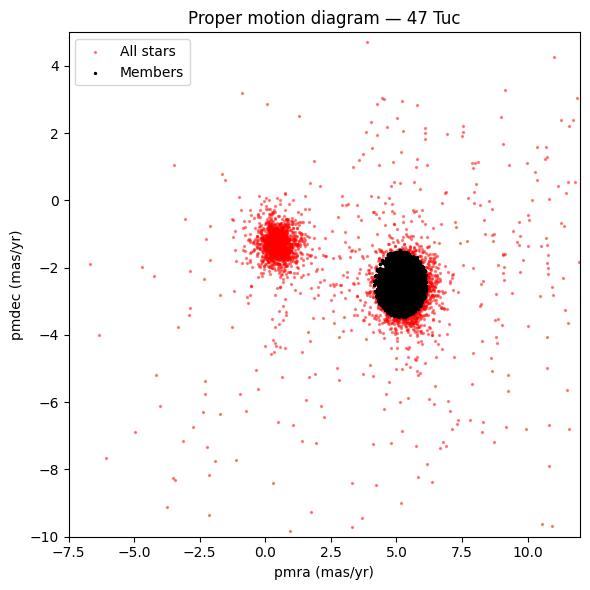

In [35]:
x_c  = np.median(pmra)
y_c  = np.median(pmdec)
mask = (pmra - x_c) ** 2 + (pmdec - y_c) ** 2 <= PM_RADIUS ** 2

print(f"Stars selected as cluster members: {mask.sum()} / {len(mask)}")

plt.figure(figsize=(6, 6))
plt.scatter(pmra, pmdec, color="red", s=2, alpha=0.4, label="All stars")
plt.scatter(pmra[mask], pmdec[mask], color="black", s=2, label="Members")
plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.xlim(-7.5, 12)
plt.ylim(-10, 5)
plt.title("Proper motion diagram — 47 Tuc")
plt.legend()
plt.tight_layout()
plt.show()

Note that the proper motion diagram shows two distinct clumps in red. The one on the left (~0, −1 mas/yr) corresponds to stars from the Small Magellanic Cloud (SMC), which lies in the same region of the sky and was captured by our Gaia query. We can identify it as the SMC because its bulk proper motion (~0.7, −1.2 mas/yr) is well established in the literature and clearly offset from that of 47 Tuc (~6.7, −2.6 mas/yr). The median proper motion of the full sample falls close enough to the 47 Tuc clump — which is denser — that our circular selection (black points) correctly isolates cluster members. However, this approach would fail if the field contamination were dominant.

### 3.5 Colour-magnitude diagram (observed)

We compute absolute G magnitudes from the parallax-based distance modulus:

$$G_{\rm abs} = G + 5\log_{10}(parallax_{\rm mas}) - 10$$

and plot the CMD for all stars and cluster members.

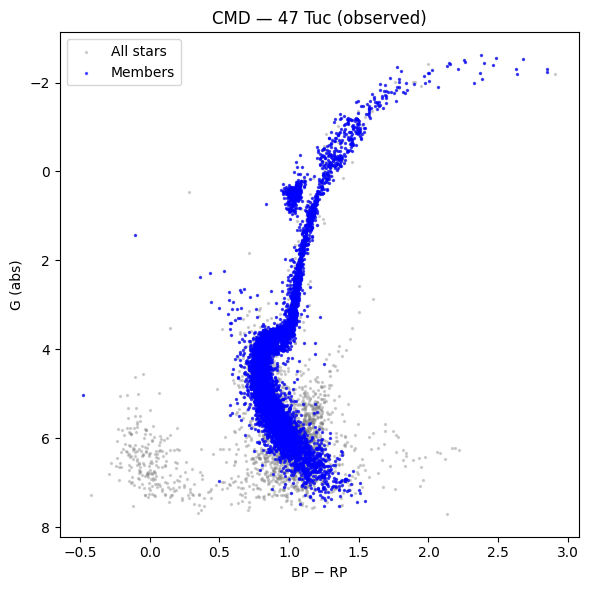

In [31]:
g_abs = df["phot_g_mean_mag"] + 5 * np.log10(parallax) - 10

plt.figure(figsize=(6, 6))
plt.scatter(bp_rp, g_abs, s=2, alpha=0.3, color="grey", label="All stars")
plt.scatter(bp_rp[mask], g_abs[mask], s=2, alpha=0.6, color="blue", label="Members")
plt.gca().invert_yaxis()
plt.xlabel("BP − RP")
plt.ylabel("G (abs)")
plt.title("CMD — 47 Tuc (observed)")
plt.legend()
plt.tight_layout()
plt.show()

The plot above is called a **Colour-Magnitude Diagram (CMD)** — one of the most powerful tools in stellar astrophysics. Let us unpack what it shows.

### Reading the CMD

The **horizontal axis** shows the colour of each star, measured as the difference between its brightness in the blue (BP) and red (RP) Gaia filters. A small BP−RP value means the star appears blue (hot); a large value means it appears red (cool).

The **vertical axis** shows the absolute magnitude G — a measure of the intrinsic luminosity of the star (brighter stars are at the top, since the axis is inverted). We convert apparent magnitudes to absolute magnitudes using the parallax-based distance.

The grey points are all stars in the field. The blue points are the cluster members selected in the previous step. Look at how the blue points trace clear, well-defined structures — this is the signature of a **coeval stellar population** (all stars born at the same time)

### Stellar evolution on the CMD

Stars spend most of their lives fusing hydrogen in their cores. During this phase they sit on a diagonal band called the **Main Sequence (MS)**, running from the bottom-right (faint, cool, low-mass stars) to the upper-left (bright, hot, massive stars). In the CMD above, the main sequence of 47 Tuc is the dense diagonal streak of blue points running from BP−RP ≈ 0.5 at the top to BP−RP ≈ 1.4 at the bottom.

When a star exhausts the hydrogen in its core, it begins to expand and cool, moving off the main sequence to the right and upward. This defines the **Sub-Giant Branch (SGB)** and the **Red Giant Branch (RGB)** — the prominent vertical structure of blue points on the right side of the CMD, reaching up to G ≈ −2.

### The main sequence turn-off: the key to age

The most important feature for age dating is the **Main Sequence Turn-Off (MSTO)** — the point where stars leave the main sequence and begin ascending the red giant branch. This happens at around BP−RP ≈ 0.8, G ≈ 0.5 in our CMD.

The position of the MSTO encodes the age of the cluster: **more massive stars evolve faster and leave the main sequence earlier**. The fainter and redder the turn-off point, the older the cluster. This is the fundamental principle behind isochrone fitting.

### 3.6 Extinction correction

In [32]:
bp_rp_0 = (phot_bp - phot_rp) - (A_BP - A_RP)      # intrinsic colour
g_0     = phot_g - A_G                             # intrinsic G magnitude

print(f"E(B-V) = {E_BV}")
print(f"A_G    = {A_G:.4f} mag")
print(f"A_BP   = {A_BP:.4f} mag")
print(f"A_RP   = {A_RP:.4f} mag")

E(B-V) = 0.03
A_G    = 0.0258 mag
A_BP   = 0.0320 mag
A_RP   = 0.0196 mag


47 Tuc has very low reddening (E(B−V) = 0.03), so the extinction corrections are small — less than 0.03 mag in G. Nevertheless, we apply them to be physically consistent before comparing with theoretical isochrones.

### 3.7 Isochrone grid

We download PARSEC isochrones for a grid of ages (10–14 Gyr) and metallicities ([M/H] = −0.9 to −0.4) and overplot them on the observed CMD. Each PDF shows a fixed age with three metallicity curves.

<div style="background-color: #ffe6e6; border-left: 5px solid red; padding: 10px; margin: 10px 0; color: #8b0000;">
<b>⚠️ Warning:</b> This section requires the PARSEC server (stev.oapd.inaf.it to be available. If it is unreachable, the pre-generated PDFs in plots/isochrones/ can be used directly. The server is down if you get: EmptyDataError: No columns to parse from file.
</div>

In [ ]:
logages = [np.log10(age * 1e9) for age in AGES_GYR]

base_cmap = cm.Reds
dark_reds  = colors.LinearSegmentedColormap.from_list(
    "dark_reds", base_cmap(np.linspace(0.4, 0.9, 256))
)

start = time.perf_counter()

for logage, age_gyr in zip(logages, AGES_GYR):
    for mhs, suffix in [(MHS_1, "1"), (MHS_2, "2")]:
        norm = colors.Normalize(vmin=min(mhs), vmax=max(mhs))
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.scatter(bp_rp[mask], g_abs[mask], s=2, color="blue", alpha=0.5, zorder=1)

        for mh in mhs:
            iso = ezpadova.get_isochrones(
                logage=(logage, logage, 0), MH=(mh, mh, 0), photsys_file=PHOTSYS
            )
            iso["BP_RP_0"] = iso["G_BPmag"] - iso["G_RPmag"]
            iso["G_0"]     = iso["Gmag"]

            ax.scatter(
                iso["BP_RP_0"], iso["G_0"],
                s=0.9, color=dark_reds(norm(mh)), alpha=0.75,
                label=f"[M/H] = {mh}", zorder=2,
            )

        ax.set_xlabel("BP − RP")
        ax.set_ylabel("G")
        ax.set_xlim(0, 3)
        ax.set_ylim(9, -3)
        ax.set_title(f"Isochrones — {age_gyr:.1f} Gyr")
        ax.legend()
        fig.savefig(f"plots/isochrones/isochrones_{age_gyr:.1f}Gyr_{suffix}.pdf")
        plt.close(fig)

end = time.perf_counter()
print(f"Isochrone grid completed in {end - start:.2f} s")

### 3.8 Best-fit isochrone selection

After inspecting the full grid of PDFs, we select the isochrone that best reproduces the observed CMD — focusing primarily on the **main sequence turn-off point** (fitting the isochrone to the leftmost edge of the main sequence) and the **red giant branch** slope.

The figure below shows the best match from the grid:

![Best-fit isochrone](plots/isochrones/isochrones_13.5Gyr_1.png)

> **Best fit: 13.5 Gyr, [M/H] = −0.6**

The isochrone at 13.5 Gyr and [M/H] = −0.6 traces the main sequence and the red giant branch of 47 Tuc more faithfully than any other combination in the grid. Younger ages produce a turn-off that is too blue; older metallicities shift the red giant branch too far to the right.

The code cell below generates this plot when the PARSEC server is available:

<div style="background-color: #ffe6e6; border-left: 5px solid red; padding: 10px; margin: 10px 0; color: #8b0000;">
<b>⚠️ Warning:</b> This section requires the PARSEC server (<code>stev.oapd.inaf.it</code>) to be available. If it is unreachable, the pre-generated PDFs in <code>plots/isochrones/</code> can be used directly. The server is down if you get: <code>EmptyDataError: No columns to parse from file</code>.
</div>

In [ ]:
logage_best = np.log10(BEST_AGE_GYR * 1e9)

iso_best = ezpadova.get_isochrones(
    logage=(logage_best, logage_best, 0),
    MH=(BEST_MH, BEST_MH, 0),
    photsys_file=PHOTSYS,
)

iso_best["BP_RP_0"] = iso_best["G_BPmag"] - iso_best["G_RPmag"]
iso_best["G_0"]     = iso_best["Gmag"]

plt.figure(figsize=(6, 6))
plt.scatter(bp_rp_0[mask], g_0[mask], s=2, color="blue", alpha=0.5, label="47 Tuc (dereddened)")
plt.scatter(iso_best["BP_RP_0"], iso_best["G_0"], s=1, color="red",
            label=f"PARSEC {BEST_AGE_GYR} Gyr, [M/H] = {BEST_MH}")
plt.xlabel("(BP − RP)₀")
plt.ylabel("G₀")
plt.title(f"Best-fit CMD — {BEST_AGE_GYR} Gyr, [M/H] = {BEST_MH}")
plt.xlim(0, 3)
plt.ylim(9, -3)
plt.legend()
plt.tight_layout()
plt.show()

---

## 4. Results and discussion

### Best-fit parameters

| Parameter | This work | Literature |
|-----------|-----------|------------|
| Age | **13.5 Gyr** | 12.0–13.8 Gyr |
| Metallicity [M/H] | **−0.6** | −0.72 (Harris 1996) |

Our result is fully consistent with published values. The slight differences in metallicity between our best fit (−0.6) and the Harris catalogue value (−0.72) are within the spacing of our grid (0.1 dex) and expected given our visual fitting approach.

### What does 13.5 Gyr mean?

The age of the Universe according to the standard ΛCDM cosmological model is ~13.8 Gyr. A cluster age of 13.5 Gyr places the formation of 47 Tuc just ~300 million years after the Big Bang — making it one of the earliest structures to have formed in the Milky Way. This is consistent with the picture of globular clusters as relics of the first episodes of star formation in the early Universe.

### Caveats and limitations

This analysis has several important limitations worth noting:

- **Visual fitting** — the best-fit isochrone was selected by eye rather than through a formal statistical minimisation (e.g. χ² or Bayesian inference). This introduces subjectivity and does not provide formal uncertainties on the age or metallicity.
- **Proper motion membership** — our circular cut in proper motion space is a simple but imperfect membership criterion. A more robust approach would use a probabilistic membership model (e.g. a Gaussian mixture model).
- **Parallax-based distances** — individual parallax measurements for stars at ~4 kpc are noisy (relative uncertainties of ~20–40%). The CMD scatter partly reflects this, not just intrinsic spread.
- **Single-population assumption** — 47 Tuc is known to host multiple stellar populations with slightly different chemical compositions. We treat it as a single population here, which is a simplification.

Despite these limitations, the result — **13.5 Gyr, [M/H] = −0.6** — is robust and consistent with dedicated studies using much more sophisticated methods. The power of the approach lies in its simplicity and the fact that it uses entirely public, real data.